# 🔎 **Proyecto Final — Análisis y Diseño de Algoritmos**
## **El problema del Camino Hamiltoniano (HAM-PATH)**
---

**Autores:** Juan Diego Ramírez Sánchez, Juan Esteban Agudelo Burgos

**Curso:** Análisis y Diseño de Algoritmos (ADA)

**Fecha:** 14 de julio de 2026

<br>

> Estudio comparativo de cuatro enfoques algorítmicos —**Fuerza Bruta**, **Backtracking**,
> **Programación Dinámica** y un **algoritmo probabilístico de Monte Carlo**— para resolver
> un problema **NP-Completo**: el del **Camino Hamiltoniano**. El notebook implementa cada
> enfoque, analiza su complejidad, valida su corrección con pruebas automatizadas y sienta
> la base para la experimentación empírica.

## **0. Instrucciones de uso**
---

Este notebook está diseñado para ejecutarse en **Google Colab** de principio a fin. Para
reproducir los resultados, siga estas indicaciones:

<br>

**▸ Orden de ejecución.** Ejecute las celdas **secuencialmente, de arriba hacia abajo**
(`Entorno de ejecución → Ejecutar todas`). Varias secciones reutilizan objetos, funciones y
librerías definidos en celdas anteriores, por lo que saltarse una celda puede producir
errores de nombre no definido.

**▸ Dependencias.** La primera celda de código instala e importa todo lo necesario
(`networkx`, `matplotlib`, `pandas`, `pytest`/`ipytest`, etc.). En Colab estas librerías ya
vienen preinstaladas casi en su totalidad; la celda de instalación se conserva por
reproducibilidad.

**▸ Reproducibilidad.** Todos los trazados de grafos usan una semilla fija
(`nx.spring_layout(G, seed=...)`) para que la disposición visual sea idéntica entre corridas.
Los algoritmos con componente aleatorio (Monte Carlo) exponen un parámetro `seed` que permite
fijar la secuencia pseudoaleatoria.

<br>

**▸ Contrato común de los algoritmos.** Con el fin de que los cuatro enfoques sean
**intercambiables** (esencial para la experimentación de la Parte 2), todas las funciones que
resuelven el problema respetan la misma firma:

- **Entrada:** un grafo no dirigido como objeto `networkx.Graph` (más los parámetros propios
  de cada enfoque, si aplica).
- **Salida:** una pareja `(P, R)`, donde:
  - `P` es la **lista ordenada de vértices** del camino hamiltoniano hallado
    `[v₁, v₂, …, vₙ]`, o `None` si no existe ninguno.
  - `R` es el **valor booleano** de la *versión de decisión* del problema: `True` si el grafo
    admite un camino hamiltoniano, `False` en caso contrario.
  - Se cumple invariablemente la coherencia `R == (P is not None)`.

<br>

**▸ Organización del notebook.**

| Sección | Contenido |
|---|---|
| 1 | Definición formal del problema (búsqueda y decisión). |
| 2 | Los cuatro enfoques: teoría, implementación, complejidad y prueba visual. |
| 3 | Diseño de casos de prueba y verificación automatizada con `pytest`. |
| 4 | Configuración del entorno experimental (Parte 2). |
| 5 | Infraestructura del experimento y recolección de métricas. |
| 6 | Análisis estadístico y visualización de resultados. |

## **1. Definición formal del problema**
---

Antes de abordar los algoritmos, fijamos con precisión el objeto de estudio. Las siguientes
definiciones establecen la terminología y la notación que se usará de forma consistente a lo
largo de todo el notebook.

<br>

<font color="turquoise">Definición (Grafo no dirigido).</font> Un *grafo no dirigido* es un
par $G = (V, E)$ donde $V$ es un conjunto finito de **vértices** y
$E \subseteq \{\, \{u, v\} : u, v \in V \}$ es un conjunto de **aristas**,
entendidas como pares **no ordenados** de vértices. Escribimos $n = \vert V \vert$
para el número de vértices.

<br>

<font color="turquoise">Definición (Camino).</font> Sean $x$ y $y$ vértices de $G = (V, E)$.
Un *camino* de $x$ a $y$ es una sucesión de vértices $\langle v_1, v_2, \dots, v_k \rangle$
tal que $v_1 = x$, $v_k = y$ y $\{v_i, v_{i+1}\} \in E$ para todo $1 \leq i \leq k-1$; es
decir, cada par de vértices consecutivos es adyacente.

<br>

<font color="turquoise">Definición (Camino simple).</font> Un camino
$\langle v_1, v_2, \dots, v_k \rangle$ se dice *simple* si **no repite vértices**, esto es,
$v_i \neq v_j$ siempre que $i \neq j$.

<br>

<font color="turquoise">Definición (Camino hamiltoniano).</font> Un *camino hamiltoniano* de
$G = (V, E)$ es un camino simple $\langle v_1, v_2, \dots, v_n \rangle$ que **visita cada
vértice de $V$ exactamente una vez**; formalmente, $\{v_1, v_2, \dots, v_n\} = V$ con
$v_i \neq v_j$ para $i \neq j$. Nótese que, a diferencia del *ciclo* hamiltoniano, **no** se
exige que el vértice final sea adyacente al inicial ni que se regrese al punto de partida.

<br>

### 📌 **1.1. Problema de búsqueda (versión original)**
---

Dado un grafo no dirigido $G = (V, E)$ con $\vert V \vert = n$, el **Hamilton Path problem**
(abreviado **HAM-PATH**) consiste en hallar una secuencia ordenada de vértices

$$P = \langle v_1, v_2, \dots, v_n \rangle$$

que satisfaga simultáneamente las tres condiciones:

1. $\{v_1, v_2, \dots, v_n\} = V$ &nbsp; (el camino incluye **todos** los vértices).
2. $v_i \neq v_j$ para todo $i \neq j$ &nbsp; (ningún vértice se **repite**).
3. $\{v_i, v_{i+1}\} \in E$ para todo $1 \leq i \leq n-1$ &nbsp; (los vértices consecutivos
   son **adyacentes**).

Si tal secuencia $P$ existe, se devuelve; en caso contrario, se reporta su inexistencia.

<br>

### 📌 **1.2. Versión de decisión**
---

Para analizar la complejidad del problema y ubicarlo dentro de la jerarquía de clases,
lo reformulamos como un **problema de decisión**, cuya respuesta a cada instancia es binaria:

<br>

**Entrada:** un grafo no dirigido $G = (V, E)$.

**Pregunta:** ¿existe en $G$ un camino hamiltoniano, es decir, un orden
$\langle v_1, \dots, v_n \rangle$ de sus vértices que cumpla las tres condiciones de la
sección 1.1?

**Salida:** <font color="lime">**SÍ**</font> si dicho camino existe;
<font color="#FF4521">**NO**</font> en caso contrario.

<br>

Formalmente, el lenguaje asociado al problema es

$$\text{HAM-PATH} = \{\, \langle G \rangle \ \vert\ G \text{ es un grafo que contiene un camino hamiltoniano} \,\}.$$

## **2. Implementación de los enfoques**
---

En esta sección se implementan y analizan los cuatro enfoques que resuelven el problema
HAM-PATH: **Fuerza Bruta**, **Backtracking**, **Programación Dinámica** (Held–Karp) y un
**algoritmo probabilístico de Monte Carlo**. Cada enfoque se desarrolla con la misma
estructura —elucidación teórica, implementación, análisis de complejidad y prueba de
ejecución— y todos respetan el contrato común `(P, R)` descrito en las instrucciones de uso.

<br>

### **Instancia de demostración compartida**

Para que las pruebas de ejecución sean **comparables**, los cuatro enfoques se ejecutan sobre
una **misma instancia** $G_\text{demo}$: un grafo pequeño de 5 vértices
$V = \{A, B, C, D, E\}$ cuyas aristas son

$$E = \{\, \{A,B\},\ \{A,C\},\ \{A,D\},\ \{A,E\},\ \{B,C\},\ \{D,E\} \,\}.$$

Esta instancia **posee** al menos un camino hamiltoniano (p. ej. $B \to C \to A \to D \to E$),
por lo que sirve de control positivo uniforme. Se define también una función reutilizable
`dibujar_camino(...)` que resalta en verde los nodos y aristas del camino hallado y numera el
orden de visita.

In [53]:
import itertools
import networkx as nx
import matplotlib.pyplot as plt

# --- Instancia de demostración compartida por los cuatro enfoques ---
v = ["A", "B", "C", "D", "E"]
e  = [("A", "B"), ("A", "C"), ("A", "D"), ("A", "E"), ("B", "C"), ("D", "E")]

G_demo = nx.Graph()
G_demo.add_nodes_from(v)
G_demo.add_edges_from(e)


def dibujar_camino(G, path, titulo="", seed=42):
    """
    Dibuja el grafo 'G' resaltando el camino hamiltoniano 'path'.

    - El grafo base se dibuja en gris.
    - Los nodos y aristas del camino se resaltan en verde.
    - Los números sobre los nodos indican el orden de visita (1, 2, ..., n).

    Parámetros:
    - G     (networkx.Graph): grafo de entrada.
    - path  (list | None)   : lista de vértices del camino; si es None no se resalta nada.
    - titulo (str)          : título de la figura.
    - seed  (int)           : semilla del layout para una disposición reproducible.
    """
    pos = nx.spring_layout(G, seed=seed)   # layout fijo -> figura reproducible
    plt.figure(figsize=(5, 4))

    # Grafo base (todos los nodos y aristas en gris)
    nx.draw(G, pos, with_labels=True, node_color="lightgray", edgecolors="black",
            linewidths=1.5, node_size=800, font_size=12, font_weight="bold",
            edge_color="lightgray")

    if path:
        # Nodos del camino en verde
        nx.draw_networkx_nodes(G, pos, nodelist=path, node_color="#22C55E",
                               edgecolors="black", linewidths=1.5, node_size=800)
        # Aristas del camino en verde
        path_edges = list(zip(path[:-1], path[1:]))
        nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color="#16A34A", width=3)
        # Orden de visita sobre cada nodo del camino
        for orden, v in enumerate(path, start=1):
            x, y = pos[v]
            plt.text(x, y + 0.12, str(orden), fontsize=10, ha="center",
                     color="darkgreen", fontweight="bold")

    plt.title(titulo, fontsize=12)
    plt.axis("off")
    plt.show()

### **Enfoque 1 — Fuerza Bruta**

Este primer enfoque resuelve el problema mediante una **búsqueda exhaustiva**: dado que un
camino hamiltoniano no es más que una **ordenación de los $n$ vértices** que respeta las
adyacencias, basta con **enumerar todas las ordenaciones posibles** y comprobar, una por una,
si alguna constituye un camino válido.

<br>

#### **1.1. Elucidación teórica**

**Idea general.** El espacio de soluciones candidatas es el conjunto de **todas las
permutaciones** de $V$. Hay exactamente $n!$ de ellas. Cada permutación
$\langle v_1, v_2, \dots, v_n \rangle$ es un camino hamiltoniano si y solo si **cada par de
vértices consecutivos es adyacente** en $G$; es decir, si $\{v_i, v_{i+1}\} \in E$ para todo
$1 \leq i \leq n-1$. Las condiciones 1 y 2 de la sección 1.1 (cubrir todos los vértices sin
repetir) se satisfacen **automáticamente**, pues toda permutación de $V$ es, por construcción,
una ordenación de los $n$ vértices sin repeticiones. Por tanto, el único predicado que resta
comprobar es la **condición 3** (adyacencia).

<br>

**Lógica del algoritmo.**

1. Se obtiene la lista de vértices y se genera, con `itertools.permutations`, cada una de las
   $n!$ ordenaciones **de forma perezosa** (una a la vez, sin materializarlas todas).
2. Para cada permutación que constituye un camino candidato se evalúa la adyacencia entre vértices consecutivos en la lista; en cuanto encuentra un par consecutivo no adyacente, se descarta de inmediato ese candidato.
3. La primera permutación que supera la comprobación se devuelve como camino hamiltoniano,
   junto con `R = True`.
4. Si se agotan las $n!$ permutaciones sin éxito, se concluye que el grafo **no** admite
   camino hamiltoniano y se retorna `(None, False)`.

<br>

**Precisiones técnicas.**

- El enfoque **no incorpora ninguna poda**: incluso si un prefijo ya viola una adyacencia, la
  enumeración de permutaciones no lo aprovecha para descartar de golpe todas las
  ordenaciones que comparten ese prefijo (esa mejora es, precisamente, la que introduce el
  Enfoque 2 - Backtracking).
- El caso $n = 1$ se maneja de forma natural: la única permutación es $\langle v_1 \rangle$ y
  el bucle de comprobación es vacío, por lo que se devuelve $([v_1], \text{True})$.

#### **Implementación**

In [54]:
def ham_path_fuerza_bruta(G):
    """
    Resuelve HAM-PATH por fuerza bruta: enumera TODAS las permutaciones de los
    vértices y comprueba si alguna constituye un camino hamiltoniano.

    Parámetros:
    - G (networkx.Graph): grafo no dirigido de entrada.

    Retorna:
    - (P, R) donde:
        P (list | None): lista [v1, ..., vn] del primer camino hamiltoniano
                         encontrado, o None si no existe.
        R (bool)       : True si G admite un camino hamiltoniano; False si no.
    """
    vertices = list(G.nodes())
    n = len(vertices)

    # Grafo sin vértices: no hay camino que reportar.
    if n == 0:
        return None, False

    # Se examinan las n! ordenaciones posibles de los vértices (de forma perezosa).
    for path in itertools.permutations(vertices):
        # Una permutación es camino hamiltoniano si todo par consecutivo es arista.

        es_camino = True

        for i in range(n-1):
          if not G.has_edge(path[i], path[i+1]):
            es_camino = False
            break

        if es_camino:
            return list(path), True

    # Ninguna permutación resultó ser un camino hamiltoniano.
    return None, False

#### **1.2. Análisis de la complejidad temporal y espacial**

**Complejidad temporal.**

El costo total es el producto del **tamaño del espacio de búsqueda** por el **costo de
procesar cada candidato**. El número de permutaciones de $n$ vértices es

$$\vert S_n \vert = n!$$

y, para cada uno, la comprobación de adyacencia recorre los $n-1$ pares consecutivos. Cada
consulta `G.has_edge(u, v)` cuesta $O(1)$, pues `networkx` almacena la adyacencia como un
diccionario de diccionarios (búsqueda por *hash*). Así, verificar una permutación cuesta
$O(n)$. En el **peor caso** —cuando el grafo no tiene camino hamiltoniano y deben examinarse
todas las permutaciones, o cuando la única válida es la última— se obtiene:

$$T(n) = O(n \cdot n!)$$

Por la aproximación de Stirling, $n! \approx \sqrt{2\pi n}\,\left(\tfrac{n}{e}\right)^{n}$, de
modo que este crecimiento es **superexponencial** y, en particular, **más costoso que el
$O(2^n)$** de los enfoques con poda que se estudian a continuación.

<br>

**Complejidad espacial.**

`itertools.permutations` es un **generador perezoso**: produce las permutaciones de a una y
mantiene únicamente un estado interno de tamaño $O(n)$, en lugar de materializar las $n!$
ordenaciones en memoria. A ello se suman la lista `vertices` y la permutación en curso, ambas
de tamaño $O(n)$. Por consiguiente,

$$S(n) = O(n)$$

#### **1.3. Prueba de ejecución**

Enfoque 1 — Fuerza Bruta
¿Existe camino hamiltoniano en G_demo?  R = True
Camino hallado:  P = ['B', 'C', 'A', 'D', 'E']
Recorrido:  B ➜ C ➜ A ➜ D ➜ E



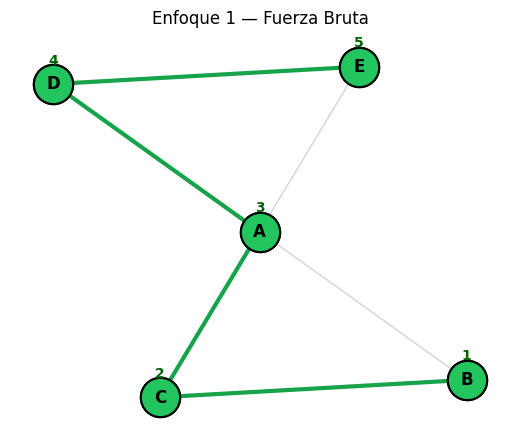

In [55]:
# --- Prueba de ejecución sobre la instancia compartida G_demo ---
P, R = ham_path_fuerza_bruta(G_demo)

print("Enfoque 1 — Fuerza Bruta")
print(f"¿Existe camino hamiltoniano en G_demo?  R = {R}")
print(f"Camino hallado:  P = {P}")
if P:
    print("Recorrido:  " + " ➜ ".join(map(str, P)))

print()
# Visualización del camino sobre el grafo
dibujar_camino(G_demo, P, titulo="Enfoque 1 — Fuerza Bruta")

### **Enfoque 2 — Backtracking**

Este enfoque **refina la búsqueda exhaustiva del Enfoque 1** introduciendo **poda**. En lugar
de generar cada permutación completa de $V$ para recién entonces comprobar sus adyacencias, el
backtracking **construye el camino incrementalmente** y **abandona de inmediato** cualquier
prefijo que ya no pueda prolongarse. Con ello se evita explorar el enorme número de
ordenaciones que comparten un comienzo inviable.

<br>

#### **2.1. Elucidación teórica**

**Idea general.** El algoritmo explora un **árbol de decisión** cuyos nodos son *caminos
parciales*. La raíz de cada árbol es un vértice de inicio; descender un nivel equivale a
**extender** el camino hacia un vecino **no visitado**. Como el problema no fija un vértice de
partida, se prueba **cada vértice como posible inicio**.

<br>

**Lógica del algoritmo.**

1. Para cada vértice de inicio se arranca un camino parcial que contiene solo ese vértice.
2. Desde el último vértice del camino parcial se intenta avanzar a un vecino **no visitado**.
   Antes de añadir un candidato $v$ se comprueba que:
   - exista la arista entre el último vértice del camino y $v$ (garantizado al iterar solo
     sobre `G.neighbors(...)`), y
   - $v$ **no** haya sido visitado (para no repetir vértices).
3. **Poda (retroceso).** Si desde el vértice actual **ningún** vecino permite avanzar, el
   camino parcial es un **callejón sin salida**: se deshace la última decisión (`pop`) y se
   prueba otra alternativa en el nivel anterior. Este retroceso es lo que descarta, de un solo
   golpe, todas las permutaciones que habrían prolongado ese prefijo inviable.
4. **Caso base.** Si el camino parcial llega a contener los $n$ vértices, se ha hallado un
   camino hamiltoniano: se devuelve junto con `R = True`.
5. Si tras probar **todos** los inicios ninguna rama alcanza longitud $n$, el grafo no admite
   camino hamiltoniano y se retorna `(None, False)`.

<br>

**Relación con el Enfoque 1.** Ambos recorren, en el peor caso, el mismo espacio de $n!$
ordenaciones; la diferencia es que la fuerza bruta evalúa **cada permutación completa**,
mientras que el backtracking descarta prefijos inviables **antes** de completarlos. En grafos
**dispersos** o **sin** camino hamiltoniano, esta poda recorta drásticamente el trabajo real;
en el **peor caso** (grafo completo, donde todo prefijo es prolongable) ambos coinciden
asintóticamente.

<br>

**Precisiones técnicas.**

- La pertenencia a `visitados` se consulta sobre un `set`, con costo $O(1)$ amortizado, para no
  penalizar la comprobación de "vértice no repetido".
- Se itera `sorted(G.neighbors(actual))` para que la exploración sea **determinista** y el
  camino devuelto sea reproducible entre corridas.
- El vértice de inicio se conserva en el camino desde el arranque, por lo que el caso $n = 1$
  se resuelve de inmediato en el caso base.

#### **Implementación**

In [56]:
def ham_path_backtracking(G):
    """
    Resuelve HAM-PATH por backtracking (fuerza bruta con poda).

    Construye el camino incrementalmente y retrocede en cuanto un camino
    parcial no puede prolongarse hacia un vecino no visitado.

    Parámetros:
    - G (networkx.Graph): grafo no dirigido de entrada.

    Retorna:
    - (P, R) donde:
        P (list | None): lista [v1, ..., vn] del camino hamiltoniano hallado,
                         o None si no existe.
        R (bool)       : True si G admite un camino hamiltoniano; False si no.
    """
    n = G.number_of_nodes()

    # Grafo sin vértices: no hay camino que reportar.
    if n == 0:
        return None, False

    vertices = list(G.nodes())

    def backtrack(path, visitados):

        # Caso base: el camino parcial ya cubre los n vértices -> es hamiltoniano.
        if len(path) == n:
            return True

        actual = path[-1]

        # Se intenta extender hacia cada vecino no visitado.
        for v in sorted(G.neighbors(actual)):
            if v not in visitados:
                # Se toma la decisión de avanzar hacia v.
                path.append(v)
                visitados.add(v)

                if backtrack(path, visitados):
                    return True

                # v no condujo a una solución: se deshace la decisión (retroceso/poda).
                path.pop()
                visitados.remove(v)

        # Ningún vecino prolongó el camino: callejón sin salida.
        return False

    # Se prueba cada vértice como posible punto de partida del camino.
    for inicio in vertices:
        path = [inicio]
        visitados = {inicio}
        if backtrack(path, visitados):
            return path, True

    # Ningún inicio produjo un camino hamiltoniano.
    return None, False

#### **2.2. Análisis de la complejidad temporal y espacial**

**Complejidad temporal.**

El costo depende del tamaño del **árbol de exploración**. En el **peor caso** —un grafo
**completo** $K_n$, donde todo camino parcial puede prolongarse y la poda nunca actúa— el
algoritmo, probando los $n$ inicios posibles, recorre las $n!$ ordenaciones de los vértices.
El número de caminos parciales explorados es:

<br>

$$\begin{align*} \sum_{k=1}^{n} \frac{n!}{(n-k)!} &= \sum_{j=0}^{n-1} \frac{n!}{j!} \ \ \ \ \ (\text{Hacemos el cambio de índice} \ j = n-k) \\ &= n! \sum_{j=0}^{n-1} \frac{1}{j!} \end{align*}$$

<br>

Ahora bien, la serie de Maclaurin de la función $f(x) = e^x$ evaluada en $x=1$ da precisamente:

<br>

$$e = e^1 = \sum_{j=0}^{\infty} \frac{1}{j!} = \frac{1}{0!} + \frac{1}{1!} + \frac{1}{2!} + \frac{1}{3!} + \dots$$

<br>

Como nuestra suma es **parcial** (solo llega hasta $ = n-1$) y todos los términos son positivos, podemos acotarla como sigue:

<br>

$$\sum_{j=0}^{n-1} \frac{1}{j!} < \sum_{j=0}^{\infty} \frac{1}{j!} = e$$

<br>

Por lo tanto $\sum_{k=1}^{n} \frac{n!}{(n-k)!} < e \cdot n! = O(n!),$ y en cada nodo de la recursión se itera sobre los vecinos del vértice actual, con un costo
acotado por $O(n)$ (la consulta de pertenencia a `visitados` es $O(1)$). Por la regla de la
multiplicación:

$$T(n) = O(n \cdot n!)$$

<br>

Esta cota del **peor caso** coincide asintóticamente con la de la fuerza bruta. Sin embargo,
es una cota **pesimista**: en grafos dispersos o sin camino hamiltoniano, la poda descarta
prefijos inviables de forma temprana y el número de nodos realmente visitados es
**muchísimo menor** que $n!$. Esta es la ganancia práctica —no asintótica— del backtracking
sobre el Enfoque 1, que la experimentación de la Parte 2 pondrá en evidencia.

<br>

**Complejidad espacial.**

La memoria está dominada por la **pila de recursión**, cuya profundidad máxima es $n$ (un
camino parcial no puede superar los $n$ vértices), más el conjunto `visitados` y la lista
`path`, ambos de tamaño $O(n)$. Por lo tanto,

$$S(n) = O(n)$$

#### **2.3. Prueba de ejecución**

Enfoque 2 — Backtracking
¿Existe camino hamiltoniano en G_demo?  R = True
Camino hallado:  P = ['B', 'C', 'A', 'D', 'E']
Recorrido:  B ➜ C ➜ A ➜ D ➜ E



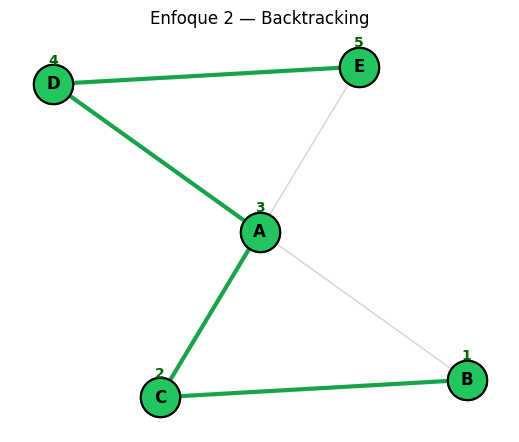

In [57]:
# --- Prueba de ejecución sobre la instancia compartida G_demo ---
P, R = ham_path_backtracking(G_demo)

print("Enfoque 2 — Backtracking")
print(f"¿Existe camino hamiltoniano en G_demo?  R = {R}")
print(f"Camino hallado:  P = {P}")
if P:
    print("Recorrido:  " + " ➜ ".join(map(str, P)))

print()
# Visualización del camino sobre el grafo
dibujar_camino(G_demo, P, titulo="Enfoque 2 — Backtracking")

### **Enfoque 3 — Procedimiento de búsqueda de Rubin (backtracking con reglas de deducción)**

Frank Rubin, en *"A Search Procedure for Hamilton Paths and Circuits"* (JACM, 1974), propone
un backtracking **inteligente** para el problema hamiltoniano. La diferencia esencial con el
Enfoque 2 es que Rubin no solo retrocede cuando un camino parcial se queda sin vecinos
disponibles, sino que, **antes** de intentar extenderlo, aplica un conjunto de **reglas de
deducción** que detectan de forma anticipada si el camino parcial es un *callejón sin salida*
—es decir, si **ningún** camino hamiltoniano puede contener ese prefijo—. En tal caso se poda
toda la rama sin explorarla.

<br>

#### **3.1. Elucidación teórica**

**El procedimiento de búsqueda (S1–S7).** Rubin estructura la búsqueda así: se elige un vértice
como camino inicial (S1); se **testea su admisibilidad** (S2); si es admisible, se listan los
vecinos del último vértice y se extiende el camino hacia el primero de ellos (S3); si es
inadmisible, se deshace el último vértice y se prueba el siguiente vecino del anterior (S4–S5);
si se agotan las extensiones desde el vértice inicial, no hay solución (S6); y si el camino
alcanza a todos los vértices, se ha hallado la solución (S7). El esqueleto es un backtracking
clásico; **la clave está en el test de admisibilidad del paso S2.**

<br>

**Clasificación de aristas (D, R, U).** Para testear un camino parcial $P$, Rubin clasifica las
aristas del grafo en tres conjuntos mutuamente excluyentes:

- $D$ (*deleted*): aristas que **no pueden** estar en ningún camino hamiltoniano que contenga a $P$.
- $R$ (*required*): aristas que **deben** estar en todo camino hamiltoniano que contenga a $P$
  (las aristas ya usadas en $P$ están en $R$).
- $U$ (*undecided*): las aristas que aún no pueden clasificarse.

En el caso **no dirigido**, la observación fundamental es que, en un camino hamiltoniano, cada
vértice tiene **grado 1** (si es un extremo del camino) o **grado 2** (si es interior). De ahí
salen deducciones inmediatas: un vértice de grado 1 en $G$ ha de ser un **extremo** y su única
arista es *requerida*; un vértice de grado 2 debe usar **ambas** aristas; y un vértice de grado 0
hace imposible el camino (salvo $n = 1$).

<br>

**Adaptación implementada.** De todo el arsenal de Rubin, nuestro test de admisibilidad implementa
un subconjunto de **reglas de fallo** que son

(i) **correctas** —solo descartan prefijos que
probablemente no completan un camino, por lo que la búsqueda sigue siendo exhaustiva y no pierde
soluciones— y

(ii) las de mayor **poder de poda**. Sea $P = \langle v_1, \dots, v_k \rangle$ el
camino parcial y $\text{last} = v_k$ su último vértice. Los vértices interiores $v_2,\dots,v_{k-1}$
ya tienen sus dos aristas del camino fijadas y el inicio $v_1$ es ya un extremo; por tanto, los
únicos vértices que aún pueden formar **nuevas aristas** del camino son $\text{last}$ y los
**pendientes** (no visitados). Llamemos $H$ al **subgrafo inducido** por
$\text{Disp} = \{\text{last}\} \cup \text{Pend}$: completar el camino equivale a hallar en $H$ un
camino hamiltoniano **con un extremo fijo en $\text{last}$**. Sobre $H$ aplicamos:

- **Regla del vértice aislado (F1).** Si algún pendiente $u$ **no** tiene vecinos en $H$
  (grado 0), nunca podrá conectarse al camino: **inadmisible**.

- **Regla de extremos (F5).** Un vértice de **grado 1** en $H$ solo puede ser un **extremo** del
  camino restante. Como $\text{last}$ ya es uno de los dos extremos, **a lo sumo un** pendiente
  puede tener grado 1 en $H$. Si **dos o más** pendientes tienen grado 1, harían falta tres
  extremos: **inadmisible**.

- **Regla de conectividad (F7 + test C1–C4).** El resto del camino ha de recorrerse continuando
  desde $\text{last}$; luego **todos** los pendientes deben ser **alcanzables** desde $\text{last}$
  dentro de $H$. Se hace un recorrido (DFS) sobre $H$; si algún pendiente queda **inalcanzable**,
  el prefijo es **inadmisible**. (Esta regla subsume, de paso, el fallo de que $\text{last}$ se
  quede sin vecinos pendientes.)

<br>

**Sobre las reglas no implementadas.** La propagación de aristas *requeridas* (`R1`, `R2`, `D1`) y
la **descomposición por $k$-conectividad** (`F9`) aportan poda adicional pero **no** alteran la
corrección; se omiten para mantener el código legible. Como se verá, el subconjunto implementado
ya reduce drásticamente el árbol de búsqueda frente al Enfoque 2.

#### **Implementación**

In [58]:
def ham_path_rubin(G):
    """
    Busca un camino hamiltoniano en G (networkx.Graph, NO dirigido) mediante el
    procedimiento de Rubin (1974): backtracking con un test de admisibilidad
    basado en reglas de deducción que podan caminos parciales inviables.

    Parámetros:
    - G (networkx.Graph): grafo no dirigido de entrada.

    Retorna:
    - (P, R) donde:
        P (list | None): lista [v1, ..., vn] del camino hamiltoniano hallado,
                         o None si no existe.
        R (bool)       : True si G admite un camino hamiltoniano; False si no.
    """
    n = G.number_of_nodes()
    if n == 0:
        return None, False

    vertices = list(G.nodes())
    sol = [None]   # almacena la solución cuando se encuentra

    def admisible(path, visitados):
        """Test de admisibilidad (paso S2): aplica las reglas de deducción sobre H."""
        last = path[-1]
        pendientes = [u for u in vertices if u not in visitados]
        if not pendientes:
            return True   # camino completo: admisible

        # H = subgrafo inducido por Disp = {last} ∪ pendientes (los que aún
        # pueden formar nuevas aristas del camino).
        disp = set(pendientes)
        disp.add(last)

        # (F1) vértice aislado  y  (F5) a lo sumo un pendiente de grado 1.
        grado_uno = 0
        for u in pendientes:
            grado_u = sum(1 for w in G.neighbors(u) if w in disp and w != u)
            if grado_u == 0:            # (F1) u nunca podrá conectarse
                return False
            if grado_u == 1:            # u solo puede ser un extremo del resto
                grado_uno += 1
                if grado_uno >= 2:      # (F5) tres extremos -> imposible
                    return False

        # (F7) conectividad: todos los pendientes alcanzables desde 'last' en H.
        permitido = set(pendientes)
        permitido.add(last)
        alcanzables = set()
        pila = [last]
        while pila:
            x = pila.pop()
            for w in G.neighbors(x):
                if w in permitido and w not in alcanzables:
                    alcanzables.add(w)
                    pila.append(w)
        return all(u in alcanzables for u in pendientes)

    def buscar(path, visitados):
        # Caso base (S7): el camino cubre los n vértices -> hamiltoniano.
        if len(path) == n:
            sol[0] = list(path)
            return True
        # (S2) Poda por deducción: si el prefijo es inadmisible, se abandona.
        if not admisible(path, visitados):
            return False
        # (S3) Extensión hacia vecinos no visitados (orden fijo -> determinista).
        for v in sorted(G.neighbors(path[-1])):
            if v not in visitados:
                path.append(v); visitados.add(v)
                if buscar(path, visitados):
                    return True
                path.pop(); visitados.remove(v)   # (S4) retroceso
        return False

    # (S1) Se prueba cada vértice como posible inicio del camino.
    for inicio in vertices:
        if buscar([inicio], {inicio}):
            return sol[0], True

    # (S6) Ningún inicio produjo un camino hamiltoniano.
    return None, False

#### **3.2. Análisis de la complejidad temporal y espacial**

Sea $n = \vert V \vert$ y $m = \vert E \vert$.

<br>

**Complejidad temporal.**

En el **peor caso** —un grafo **completo** $K_n$, donde las reglas de deducción nunca logran
podar— la búsqueda degenera en el backtracking exhaustivo: sobre los $n$ inicios posibles se
recorren del orden de $O(n!)$ caminos parciales (misma cota que en los Enfoques 1 y 2). La
diferencia es que **cada nodo de la recursión paga el costo del test de admisibilidad**, que
consta de: (i) el recorrido de los pendientes contando grados en $H$, con costo $O(n + m)$; y
(ii) el recorrido de alcanzabilidad (regla F7), también $O(n + m)$. Por tanto el test cuesta
$O(n + m)$ por nodo, y la cota del peor caso es

$$T(n) = O\big((n + m)\cdot n!\big).$$

Para grafos densos ($m = O(n^2)$), esto es $O(n^2 \cdot n!)$. **No obstante**, igual que en el
Enfoque 2, la cota es **pesimista**: el objetivo de las reglas de deducción es que, en la
práctica, el número de nodos realmente explorados sea **muchísimo menor** que $n!$. El costo
extra $O(n+m)$ por nodo es el precio de cada test de admisibilidad, y **se compensa** cuando la
poda evita explorar ramas enteras. La experimentación de la Parte 2 cuantificará este
intercambio (nodos explorados frente a costo por nodo), contrastando Rubin con el backtracking
simple.

<br>

**Complejidad espacial.**

La memoria está dominada por la **pila de recursión**, de profundidad máxima $n$. El test de
admisibilidad usa estructuras auxiliares (`pendientes`, `disp`, `alcanzables`, la pila del
recorrido), todas de tamaño $O(n)$ y **reutilizadas** en cada llamada. Sin contar el grafo de
entrada, la complejidad espacial es

$$S(n) = O(n).$$

#### **3.3. Prueba de ejecución**

Enfoque 3 — Procedimiento de búsqueda de Rubin
¿Existe camino hamiltoniano en G_demo?  R = True
Camino hallado:  P = ['B', 'C', 'A', 'D', 'E']
Recorrido:  B ➜ C ➜ A ➜ D ➜ E



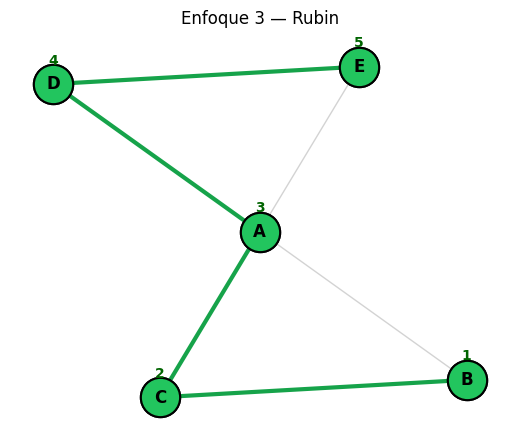

In [59]:
# --- Prueba de ejecución sobre la MISMA instancia compartida G_demo ---
P, R = ham_path_rubin(G_demo)

print("Enfoque 3 — Procedimiento de búsqueda de Rubin")
print(f"¿Existe camino hamiltoniano en G_demo?  R = {R}")
print(f"Camino hallado:  P = {P}")
if P:
    print("Recorrido:  " + " ➜ ".join(map(str, P)))

print()
# Visualización del camino sobre el grafo (reutiliza dibujar_camino de la Celda 5)
dibujar_camino(G_demo, P, titulo="Enfoque 3 — Rubin")

### **Enfoque 4 — Programación Dinámica (algoritmo de Held–Karp)**

Los tres enfoques anteriores comparten un defecto: **recalculan** una y otra vez situaciones
equivalentes. La programación dinámica ataca justamente eso, y con ello **reduce la complejidad
de $O(n!)$ a $O(2^n \cdot n^2)$** —de superexponencial a exponencial—. El precio a pagar es
**memoria exponencial**. La técnica que emplearemos es el algoritmo de **Held–Karp** (1962),
originalmente concebido para el problema del viajante (TSP) y aquí adaptado a la *existencia* de
un camino hamiltoniano.

<br>

#### **4.1. Elucidación teórica**

**La observación clave (subproblemas superpuestos).** Cuando el backtracking construye un camino
parcial, lo que necesita para decidir cómo continuar es **solo dos datos**:

(i) qué vértices ya
fueron visitados, y

(ii) en qué vértice termina el camino actual. El **orden** exacto en que se
visitaron es **irrelevante** para el futuro del recorrido. Por ejemplo, haber recorrido
$A \to B \to C$ o $B \to A \to C$ deja al algoritmo en la **misma situación**: visitados
$\{A,B,C\}$, terminando en $C$. El backtracking, sin embargo, trata esos dos caminos como
distintos y **repite** todo el trabajo posterior. Como hay hasta $n!$ órdenes pero solo
$2^n \cdot n$ situaciones distintas *(subconjunto visitado, vértice final)*, memorizar cada
situación **una sola vez** produce la mejora drástica.

<br>

**Definición del estado.** Para un subconjunto $S \subseteq V$ y un vértice $v \in S$, definimos

$$
dp[S][v] =
\begin{cases}
\text{True} & \text{si existe un camino simple que visita } \textbf{exactamente} \text{ los vértices de } S \text{ y } \textbf{termina} \text{ en } v,\\
\text{False} & \text{en caso contrario.}
\end{cases}
$$

<br>

**Codificación de subconjuntos con máscaras de bits.** Para manipular los subconjuntos $S$ con
eficiencia, no usamos estructuras de conjunto sino **máscaras de bits** (*bitmasks*):

> <font color="turquoise">Definición (Máscara de bits).</font> Fijada una numeración de los
> vértices $v_0, v_1, \dots, v_{n-1}$, una *máscara de bits* es un entero cuya representación
> binaria codifica un subconjunto $S \subseteq V$: el **bit $i$** (el $i$-ésimo bit menos
> significativo) vale $1$ si y solo si $v_i \in S$. Formalmente,
> $\text{mask}(S) = \sum_{v_i \in S} 2^i$.

Por ejemplo, con la numeración $A{=}0, B{=}1, C{=}2, D{=}3, E{=}4$, el subconjunto
$\{A, C, E\}$ se codifica como el entero $2^0 + 2^2 + 2^4 = 1 + 4 + 16 = 21$, cuya escritura
binaria es $\mathtt{10101}$ (los bits $0$, $2$ y $4$ encendidos).

<br>

**Operaciones bit a bit que usaremos.** Sobre estas máscaras, las operaciones de conjuntos se
vuelven operaciones sobre bits, todas de costo $O(1)$:

| Operación de conjuntos | Expresión con bits | Operador |
|---|---|---|
| El singleton $\{v_i\}$ | `1 << i` (es $2^i$) | `<<` (desplazamiento a la izquierda) |
| ¿$v_i \in S$? | `mask & (1 << i)` es distinto de $0$ | `&` (AND bit a bit) |
| Añadir $v_i$: $S \cup \{v_i\}$ | `mask \| (1 << i)` | `\|` (OR bit a bit) |
| Quitar $v_i$: $S \setminus \{v_i\}$ | `mask ^ (1 << i)` (si $v_i \in S$) | `^` (XOR bit a bit) |
| El conjunto total $V$ | `(1 << n) - 1` (los $n$ bits en $1$) | — |

donde `&` da $1$ solo donde **ambos** bits son $1$; `|` da $1$ donde **al menos uno** lo es; y
`^` da $1$ donde los bits **difieren** (por eso "apaga" un bit encendido).

<br>

**Caso base y recurrencia.**

- **Caso base.** Un camino de un solo vértice existe trivialmente:
  $$dp[\{v\}][v] = \text{True} \quad \text{para todo } v \in V.$$
  
- **Recurrencia.** Un camino que cubre $S$ y termina en $v$ existe si podíamos estar en algún
  vértice previo $u \in S \setminus \{v\}$ —cubriendo $S \setminus \{v\}$— y saltar a $v$ por una
  arista:
  $$dp[S][v] = \bigvee_{\substack{u \in S,\; u \neq v \\ \{u, v\} \in E}} dp[\,S \setminus \{v\}\,][u].$$

<br>

**Respuesta y reconstrucción.** El grafo admite un camino hamiltoniano si y solo si
$dp[V][v] = \text{True}$ para **algún** $v$ (es decir, se puede cubrir *todo* $V$ terminando en
algún vértice). Para **recuperar el camino** (y no solo el booleano), se guarda un puntero
`parent[S][v] = u`: el vértice previo que hizo verdadero el estado. Partiendo de un $v$ final con
$dp[V][v] = \text{True}$, se sigue la cadena de punteros hacia atrás —quitando en cada paso el
vértice actual de la máscara— hasta llegar al vértice inicial, y se invierte la secuencia.

**Nota.** Como el algoritmo reporta el primer vértice final $v$ con $dp[V][v]=\text{True}$, el
camino devuelto puede **diferir** del de otros enfoques (con frecuencia es el mismo camino en
sentido inverso), pero es igualmente válido.

#### **Implementación**

In [60]:
def ham_path_prog_dinamica(G):
    """
    Resuelve HAM-PATH por programación dinámica (algoritmo de Held-Karp) usando
    máscaras de bits para representar los subconjuntos de vértices visitados.

    dp[mask][v] = True si existe un camino simple que visita EXACTAMENTE los
    vértices indicados por 'mask' y TERMINA en el vértice de índice v.

    Parámetros:
    - G (networkx.Graph): grafo no dirigido de entrada.

    Retorna:
    - (P, R) donde:
        P (list | None): lista [v1, ..., vn] del camino hamiltoniano hallado,
                         o None si no existe.
        R (bool)       : True si G admite un camino hamiltoniano; False si no.
    """

    n = G.number_of_nodes()
    if n == 0:
        return None, False

    vertices = list(G.nodes())
    idx = {v: i for i, v in enumerate(vertices)}   # vértice -> índice de bit (0..n-1) (diccionario)
    FULL = (1 << n) - 1                            # máscara del conjunto total V

    # Tablas indexadas por (máscara, índice de vértice final).
    dp     = [[False] * n for _ in range(1 << n)]  # dp[mask][v]  -> ¿estado alcanzable?
    parent = [[-1]    * n for _ in range(1 << n)]  # predecesor para reconstruir el camino

    # --- Caso base: camino de un solo vértice {v_i}, que termina en v_i. ---
    for i in range(n):
        dp[(1 << i)][i] = True

    # --- Llenado de la tabla (recurrencia) ---
    # Se recorren las máscaras en orden creciente: añadir un vértice SIEMPRE
    # aumenta el valor entero de la máscara, así que al procesar 'mask' todos
    # sus subconjuntos con un vértice menos ya fueron resueltos.

    for mask in range(1 << n):
        for v in range(n):
            if not dp[mask][v]:
                continue   # este estado no es alcanzable; nada que propagar

            # Se intenta extender el camino (cubre 'mask', termina en v) hacia
            # un vecino w aún NO visitado.

            for w in G.neighbors(vertices[v]):
                j = idx[w]
                if mask & (1 << j):        # w ya está en el conjunto -> se repetiría
                    continue
                nueva = mask | (1 << j)    # se añade w al conjunto visitado
                if not dp[nueva][j]:
                    dp[nueva][j] = True
                    parent[nueva][j] = v   # se recuerda de dónde vino


    # --- ¿Existe camino hamiltoniano?  dp[FULL][v] para algún v. ---
    for v in range(n):
        if dp[FULL][v]:
            # Reconstrucción del camino siguiendo los punteros hacia atrás.
            path = []
            mask, u = FULL, v

            while u != -1:
                path.append(vertices[u])
                previo = parent[mask][u]
                mask ^= (1 << u)         # se quita 'u' del conjunto
                u = previo

            path.reverse()                 # se reconstruyó al revés
            return path, True

    return None, False

#### **4.2. Análisis de la complejidad temporal y espacial**

Sea $n = \vert V \vert$.

<br>

**Complejidad temporal.**

El número de **estados** es el producto del número de subconjuntos por el de posibles vértices
finales:

$$\underbrace{2^n}_{\text{subconjuntos } S} \times \underbrace{n}_{\text{vértice final } v} = O(2^n \cdot n).$$

Para cada estado $dp[S][v]$ que resulta alcanzable, la transición examina los vecinos de $v$ (a lo sumo $n-1$) y cada comprobación (pertenencia en la máscara con `&`, consulta de arista,
actualización de tabla) cuesta $O(1)$. El trabajo por estado es, pues, $O(n)$. Multiplicando:

$$T(n) = O(2^n \cdot n^2).$$

Esto representa una mejora **enorme** frente al $O(n!)$ de los enfoques previos. Por la
aproximación de Stirling, $n!$ crece **mucho** más rápido que $2^n$: para $n = 20$, se tiene
$2^{20}\cdot 20^2 \approx 4\times10^{8}$ operaciones frente a $20! \approx 2.4\times10^{18}$; el
primero es tratable en segundos y el segundo, sencillamente inabordable.

<br>

**Complejidad espacial.**

Aquí está la **contrapartida** del método. Las tablas `dp` y `parent` tienen, cada una,
$2^n \times n$ entradas. Por lo tanto,

$$S(n) = O(2^n \cdot n).$$

A diferencia del backtracking (que usa apenas $O(n)$ de memoria), Held–Karp **intercambia
espacio por tiempo**: memoriza los $O(2^n \cdot n)$ estados para no recalcularlos. Esta memoria
exponencial es la que, en la práctica, **limita** el método a valores de $n$ moderados
(típicamente hasta $n \approx 20$–$22$ en un entorno como Colab), no el tiempo. Es un punto que
la experimentación de la Parte 2 hará evidente al contrastar tiempo **y** memoria.

#### **4.3. Prueba de ejecución**

Enfoque 4 — Programación Dinámica (Held-Karp)
¿Existe camino hamiltoniano en G_demo?  R = True
Camino hallado:  P = ['E', 'D', 'A', 'C', 'B']
Recorrido:  E ➜ D ➜ A ➜ C ➜ B



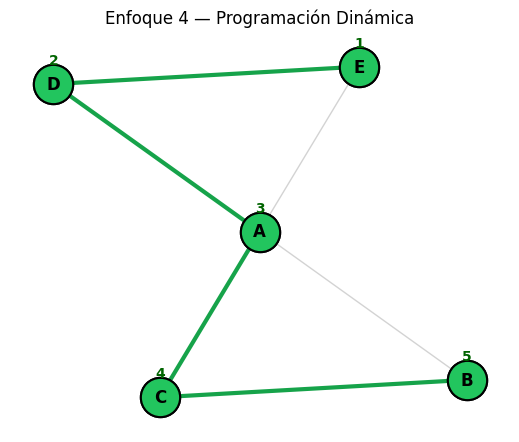

In [61]:
# --- Prueba de ejecución sobre la MISMA instancia compartida G_demo ---
P, R = ham_path_prog_dinamica(G_demo)

print("Enfoque 4 — Programación Dinámica (Held-Karp)")
print(f"¿Existe camino hamiltoniano en G_demo?  R = {R}")
print(f"Camino hallado:  P = {P}")
if P:
    print("Recorrido:  " + " ➜ ".join(map(str, P)))

print()
# Visualización del camino sobre el grafo (reutiliza dibujar_camino de la Celda 5)
dibujar_camino(G_demo, P, titulo="Enfoque 4 — Programación Dinámica")

### **Enfoque 5 — Algoritmo Probabilístico de Monte Carlo (construcción aleatoria con reinicios)**

Los cuatro enfoques anteriores son **deterministas** y **exactos**: siempre dan la respuesta
correcta. Este enfoque cambia de paradigma. Un algoritmo **probabilístico** usa el azar como
parte de su lógica y **puede equivocarse**, a cambio de ser (a menudo) mucho más rápido.

<br>

#### **5.1. Elucidación teórica**

<font color="turquoise">Definición (Algoritmo de Monte Carlo).</font> Es un algoritmo aleatorizado
que se ejecuta en un tiempo acotado pero cuya respuesta puede ser **incorrecta con cierta
probabilidad**. Se distingue del algoritmo de **Las Vegas**, que siempre responde correctamente
pero cuyo *tiempo* de ejecución es la variable aleatoria.

<font color="turquoise">Definición (Error de un solo lado).</font> Un algoritmo de decisión tiene
*error de un solo lado* si solo puede equivocarse en una de las dos respuestas. El nuestro nunca
producirá un **falso positivo**: si afirma que existe camino hamiltoniano, es porque **encontró
uno concreto** (certeza). Solo puede fallar por **falso negativo**: responder "no existe" cuando
sí existía pero el azar no dio con él.

<br>

**Idea general.** El algoritmo **construye caminos al azar** y confía en que, si hay uno
hamiltoniano, con suficientes intentos lo hallará. Cada intento es una *caminata aleatoria sin
repetición*: se parte de un vértice al azar y, en cada paso, se salta a un **vecino no visitado
elegido uniformemente al azar**. Pueden pasar dos cosas:

(i) el camino alcanza los $n$ vértices (éxito), o

(ii) se llega a un vértice sin vecinos nuevos disponibles un *atasco*, y se
**reinicia** con otro intento.

<br>

**Lógica del algoritmo.**

1. Repetir hasta `num_intentos` veces:

   a. Elegir un vértice inicial al azar.

   b. Extender el camino saltando a un vecino no visitado aleatorio, hasta completar $n$ vértices o quedar atascado.

   c. Si se completaron los $n$ vértices, devolver ese camino con `R = True` (respuesta segura).
   
2. Si ningún intento tuvo éxito, devolver `(None, False)` (posible falso negativo).

<br>

**Garantía probabilística.** Si el grafo tiene camino hamiltoniano, cada intento lo encuentra con
cierta probabilidad de éxito $q > 0$. Como los intentos son **independientes**, la probabilidad
de fallar en los $k$ intentos es $(1-q)^k$, que **decae exponencialmente** con $k$. El valor de
$q$ depende fuertemente de la **estructura** del grafo: en grafos densos es alto, mientras que en
grafos ralos puede ser diminuto (por eso el método es, en esencia, una **heurística** con
garantía de un solo lado, no un algoritmo de tiempo polinomial con error acotado como el del
Enfoque 6).

#### **Implementación**

In [62]:
import random

def ham_path_montecarlo(G, num_intentos=1000, seed=None):
    """
    Resuelve HAM-PATH por Monte Carlo: construye caminos al azar con reinicios.
    Error de un solo lado: nunca da un falso positivo (si devuelve un camino,
    es un camino hamiltoniano real); solo puede fallar por falso negativo.

    Parámetros:
    - G (networkx.Graph): grafo no dirigido de entrada.
    - num_intentos (int): número de caminos aleatorios a probar.
    - seed (int | None) : semilla para reproducibilidad del azar.

    Retorna:
    - (P, R) donde:
        P (list | None): camino hamiltoniano hallado, o None si ningún intento tuvo éxito.
        R (bool)       : True si se halló un camino; False en caso contrario.
    """
    n = G.number_of_nodes()

    if n == 0:
        return None, False

    generador = random.Random(seed)          # generador local -> reproducible
    vertices = list(G.nodes())

    for i in range(num_intentos):

        actual = generador.choice(vertices)  # vértice inicial al azar
        path = [actual]
        visitados = {actual}

        # Caminata aleatoria sin repetición.
        while len(path) < n:
            candidatos = [w for w in G.neighbors(actual) if w not in visitados]

            if not candidatos:
                break                  # atasco: se abandona este intento

            actual = generador.choice(candidatos)   # vecino nuevo al azar
            path.append(actual)
            visitados.add(actual)

        if len(path) == n:             # se cubrieron todos los vértices
            return path, True          # respuesta SEGURA (camino real)

    return None, False                 # ningún intento tuvo éxito (posible falso negativo)

#### **5.2. Análisis de la complejidad temporal y espacial**

Sea $n = \vert V \vert$, $m = \vert E \vert$ y $k$ el número de intentos.

<br>

**Complejidad temporal.** Cada intento realiza a lo sumo $n$ pasos, y en cada paso listar los vecinos no visitados cuesta $O(g(v))$ siendo $v$ el vértice actual para el intento y $g(v)$ el grado de $v$; sumado, un intento cuesta $O(n + m)$. Con $k$ intentos:

$$T(n) = O\big(k \cdot (n + m)\big).$$

Nótese que, **fijado $k$**, el costo es **polinomial**. La dificultad no está en el costo por intento, sino en **cuántos intentos** $k$ hacen falta para una probabilidad de éxito alta: en el peor caso (grafos ralos) ese número puede ser exponencial, lo que revela la naturaleza heurística del método.

<br>

**Complejidad espacial.** Cada intento solo almacena el camino y el conjunto de visitados, ambos $O(n)$:

$$S(n) = O(n).$$

#### **5.3. Prueba de ejecución**

Enfoque 5 — Monte Carlo (construcción aleatoria con reinicios)
¿Existe camino hamiltoniano en G_demo?  R = True
Camino hallado:  P = ['E', 'D', 'A', 'C', 'B']
Recorrido:  E ➜ D ➜ A ➜ C ➜ B



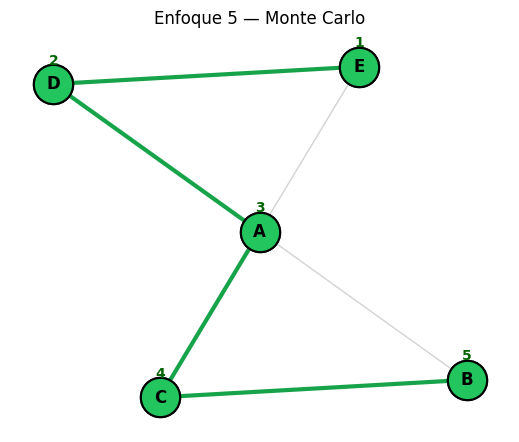

In [63]:
# --- Prueba de ejecución sobre la MISMA instancia compartida G_demo ---
P, R = ham_path_montecarlo(G_demo, num_intentos=1000, seed=42)

print("Enfoque 5 — Monte Carlo (construcción aleatoria con reinicios)")
print(f"¿Existe camino hamiltoniano en G_demo?  R = {R}")
print(f"Camino hallado:  P = {P}")
if P:
    print("Recorrido:  " + " ➜ ".join(map(str, P)))

print()
dibujar_camino(G_demo, P, titulo="Enfoque 5 — Monte Carlo")

## **3. Diseño de casos de prueba**
---

Para asegurar que los cinco enfoques son correctos, se diseña una **suite de pruebas unitarias
automatizadas** con `pytest`. La estrategia combina

(i) **casos conocidos**

(ii) una **función verificadora** que valida la corrección estructural de cada
camino devuelto, y

(iii) una **validación cruzada** contra la fuerza bruta como *oráculo de
verdad* sobre grafos aleatorios.

<br>

##### **3.1. Casos a cubrir: mejor, peor y promedio**

Siguiendo el análisis clásico de casos, la batería de pruebas cubre el espectro de dificultad:

- **Mejor caso.** El grafo **completo** $K_n$: como toda ordenación de los vértices es un camino
  hamiltoniano, los algoritmos de búsqueda encuentran uno en el primer intento (trabajo mínimo).
  Respuesta esperada: **SÍ**.

- **Peor caso.** Instancias **sin** camino hamiltoniano, que obligan a los algoritmos exactos a
  **agotar el espacio de búsqueda** antes de poder concluir "no existe". Se incluyen tres
  familias donde la ausencia es *demostrable*:
  - la **estrella** $K_{1,k}$ ($k \geq 3$): un camino no puede pasar dos veces por el centro, y
    con tres o más hojas es imposible enlazarlas;
  - el **bipartito completo desbalanceado** $K_{2,5}$: en un grafo bipartito un camino
    hamiltoniano debe **alternar** lados, luego los tamaños de las partes han de diferir en a lo
    sumo $1$ (aquí difieren en $3$);
  - un grafo **disconexo**: es imposible recorrer componentes separadas en un solo camino.

- **Caso promedio.** Grafos **aleatorios** $G(n, p)$ de respuesta variable, verificados contra la
  fuerza bruta para tamaños pequeños; capturan el comportamiento *típico*.
  
- **Casos borde.** El **grafo vacío** (sin vértices, $n = 0$, caso degenerado que todos los
  algoritmos manejan por separado: respuesta **NO**); un solo vértice (**SÍ**); y dos vértices
  con arista (**SÍ**) o sin ella (**NO**).

<br>

> **Sobre el Monte Carlo.** Al ser probabilístico, no se le exige lo mismo. Su prueba valida dos
> garantías: que **nunca** produce un falso positivo (todo camino que reporta es válido y, en los
> casos sin solución, responde **NO**), y que —con suficientes intentos— **sí** halla el camino
> en los casos con solución.

### **3.2. Configuración del entorno de prueba**

**Pytest** es un framework de testing en Python que permite ejecutar pruebas unitarias de forma
sistemática. Como estamos en Google Colab (un entorno de notebooks), usamos `ipytest`, que
permite lanzar `pytest` directamente desde una celda mediante la *magic* `%%ipytest`. La siguiente
celda instala y configura el entorno:

In [64]:
%pip install ipytest pytest

import ipytest
import pytest

ipytest.autoconfig()

### **3.3. Función verificadora**

Todas las pruebas se apoyan en una única **función verificadora**, `es_camino_hamiltoniano`, que
comprueba si una lista de vértices `P` es un camino hamiltoniano **estructuralmente válido** de
`G`. Verifica las tres condiciones de la definición formal (sección 1.1): que `P` tenga
exactamente $n$ vértices, que los cubra **todos sin repetir**, y que cada par consecutivo sea una
**arista**.

In [65]:
def es_camino_hamiltoniano(G, P):
    """
    Verifica que P sea un camino hamiltoniano VÁLIDO del grafo G.

    Comprueba las tres condiciones de la definición formal:
    (1) P cubre exactamente los n vértices,
    (2) sin repeticiones, y
    (3) cada par de vértices consecutivos es una arista de G.

    Retorna True si P es un camino hamiltoniano válido; False en caso contrario
    (incluido el caso P = None).
    """
    if P is None:
        return False
    n = G.number_of_nodes()
    if len(P) != n:                 # debe tener exactamente n vértices
        return False
    if set(P) != set(G.nodes()):    # cubre TODOS los vértices, sin repetir
        return False
    return all(G.has_edge(P[i], P[i + 1]) for i in range(n - 1))  # aristas consecutivas

### **3.4. Batería de casos de prueba**

Se agrupan los **algoritmos exactos** en una lista y se define la batería de casos como una lista
de tuplas con el formato `(G, respuesta_esperada, nombre_caso)`, cubriendo los escenarios
descritos en la sección 3.1.

In [66]:
# --- Algoritmos EXACTOS (deterministas) que deben acertar SIEMPRE ---
algoritmos_exactos = [
    ham_path_fuerza_bruta,
    ham_path_backtracking,
    ham_path_rubin,
    ham_path_prog_dinamica,
]

# --- Constructor de una instancia disconexa (dos triángulos sin unir) ---
def _grafo_disconexo():
    G = nx.Graph()
    G.add_edges_from([(0, 1), (1, 2), (2, 0)])   # triángulo 1
    G.add_edges_from([(3, 4), (4, 5), (5, 3)])   # triángulo 2 (sin conexión con el 1)
    return G

# --- Batería de casos: (G, respuesta_esperada, nombre_caso) ---
casos_prueba = [
    # Casos borde
    (nx.empty_graph(0),                False, "grafo_vacio"),
    (nx.empty_graph(1),                True,  "un_vertice"),
    (nx.path_graph(2),                 True,  "dos_vertices_con_arista"),
    (nx.empty_graph(2),                False, "dos_vertices_sin_arista"),
    # Mejor caso (grafo completo)
    (nx.complete_graph(5),             True,  "completo_K5_mejor_caso"),
    (nx.complete_graph(6),             True,  "completo_K6_mejor_caso"),
    # Casos con solución (promedio / estructurados)
    (nx.path_graph(6),                 True,  "camino_P6"),
    (nx.cycle_graph(6),                True,  "ciclo_C6"),
    (nx.petersen_graph(),              True,  "grafo_de_petersen"),
    (G_demo,                           True,  "instancia_demo"),
    # Peor caso (sin camino hamiltoniano)
    (nx.star_graph(4),                 False, "estrella_K1_4_sin_camino"),
    (nx.complete_bipartite_graph(2, 5),False, "bipartito_K2_5_sin_camino"),
    (_grafo_disconexo(),               False, "grafo_disconexo"),
]

### **3.5. Pruebas parametrizadas de los algoritmos exactos**

Mediante el decorador `@pytest.mark.parametrize` se inyectan las dos listas (algoritmos y casos),
de modo que `pytest` ejecuta automáticamente cada algoritmo contra cada caso. Por cada
combinación se verifica que:

(i) la **decisión** `R` coincide con la respuesta esperada, y

(ii) si `R` es `True`, el camino `P` es **estructuralmente válido** (con la función verificadora); si es `False`, `P` es `None`.

En total se ejecutan $4 \text{ (algoritmos)} \times 13 \text{ (casos)} = 52$ pruebas.

In [67]:
%%ipytest

@pytest.mark.parametrize("algoritmo", algoritmos_exactos)
@pytest.mark.parametrize("G, esperado, nombre", casos_prueba)

def test_algoritmos_exactos(algoritmo, G, esperado, nombre):
    """Valida que cada algoritmo exacto decida y construya correctamente en cada caso."""
    P, R = algoritmo(G)

    # (1) La decisión debe coincidir con la respuesta esperada.
    assert R == esperado, f"Decisión incorrecta en '{nombre}' con {algoritmo.__name__}"

    # (2) Coherencia entre P y R.
    if R:
        assert es_camino_hamiltoniano(G, P), \
            f"Camino inválido en '{nombre}' con {algoritmo.__name__}"
    else:
        assert P is None, \
            f"Se esperaba P = None en '{nombre}' con {algoritmo.__name__}"

....................................................                                         [100%]
52 passed in 0.13s


### **3.6. Prueba específica del algoritmo Monte Carlo**

El enfoque probabilístico se prueba aparte, con criterios acordes a su naturaleza. Fijamos una
semilla y un número alto de intentos (`num_intentos = 5000`) para que la prueba sea
**reproducible** y no *inestable*. Se validan las garantías del **error de un solo lado**:

- Si reporta un camino, este debe ser **válido** (nunca un falso positivo).
- En los casos **sin** solución, debe responder `False`.
- En los casos **con** solución, con suficientes intentos debe **hallar** el camino.

In [68]:
%%ipytest

@pytest.mark.parametrize("G, esperado, nombre", casos_prueba)

def test_algoritmo_montecarlo(G, esperado, nombre):
    """Valida las garantías (error de un solo lado) del enfoque de Monte Carlo."""
    P, R = ham_path_montecarlo(G, num_intentos=5000, seed=123)

    # (1) Solidez: si reporta un camino, debe ser válido (nunca falso positivo).
    if R:
        assert es_camino_hamiltoniano(G, P), \
            f"Falso positivo o camino inválido en '{nombre}'"

    # (2) En casos SIN solución, no puede inventar un camino.
    if not esperado:
        assert R is False, f"Monte Carlo reportó un camino inexistente en '{nombre}'"

    # (3) En casos CON solución, con 5000 intentos debe hallarlo.
    if esperado:
        assert R is True, \
            f"Monte Carlo no halló el camino en '{nombre}' (considere subir num_intentos)"

.............                                                                                [100%]
13 passed in 0.07s


### **3.7. Validación cruzada con instancias aleatorias**

Como prueba final y más exigente, se contrastan los algoritmos entre sí sobre **grafos aleatorios**
$G(n, p)$. La **fuerza bruta** actúa como *oráculo de verdad* (es la implementación más simple y
directa, por tanto la de menor riesgo de error), y se exige que los demás algoritmos exactos
coincidan con ella tanto en la **decisión** como en la **validez** del camino. Se ejecutan 100
grafos aleatorios de tamaño $n \in [1, 7]$.

In [69]:
%%ipytest
import random

def test_validacion_cruzada_aleatoria():
    """Compara los algoritmos exactos contra la fuerza bruta sobre grafos aleatorios."""
    random.seed(2024)
    for i in range(100):
        n = random.randint(1, 7)
        p = random.random()
        G = nx.gnp_random_graph(n, p, seed=random.randint(0, 10**6))

        # Oráculo de verdad: la fuerza bruta.
        i, verdad = ham_path_fuerza_bruta(G)

        # Los demás algoritmos exactos deben coincidir con fuerza bruta.
        for algoritmo in [ham_path_backtracking, ham_path_rubin, ham_path_prog_dinamica]:
            P, R = algoritmo(G)
            assert R == verdad, \
                f"{algoritmo.__name__} discrepa de la fuerza bruta (R={R}, verdad={verdad})"
            if R:
                assert es_camino_hamiltoniano(G, P), \
                    f"{algoritmo.__name__} devolvió un camino inválido"

.                                                                                            [100%]
1 passed in 0.03s


# ⚙️ **FASE 2 — Diseño experimental y recolección de datos**
---

En esta fase medimos empíricamente el rendimiento de los cinco enfoques. Siguiendo las buenas
prácticas de investigación empírica (medición rigurosa, repetición, documentación y
reproducibilidad), el flujo se organiza en dos etapas **desacopladas**:

1. **Generación de datos** (Secciones 4 y 5): un arnés experimental **portable** ejecuta los
   algoritmos sobre instancias de tamaño creciente, mide tiempo, operaciones y memoria, y
   **vuelca los resultados brutos a archivos CSV**. Esta etapa está pensada para ejecutarse en
   un **entorno local dedicado** (p. ej. VS Code), que ofrece tiempos de CPU estables, sin
   límites de sesión y con hardware documentado.
2. **Análisis y visualización** (Sección 6): el notebook **carga los CSV** y produce las
   estadísticas y gráficas. Al estar separada de la generación, esta etapa es **liviana y
   re-ejecutable por cualquier persona que quiera replicar los resultados** sin repetir el costoso barrido experimental.

Todo el código es portable: corre igual en Colab o en un entorno local; solo cambian *dónde* se
genera la carga pesada y *hasta qué tamaño* $n$ es computacionalmente factible para cada algoritmo.

<br>

## **4. Configuración del entorno experimental**
---

<br>

### **4.1. Instalación e importación de librerías**

Se instalan e importan las librerías necesarias. En Colab casi todas vienen preinstaladas; la
celda de instalación se conserva por reproducibilidad. En un entorno local, basta con
`pip install networkx pandas matplotlib psutil`.

In [70]:
%pip install networkx pandas matplotlib psutil

# --- Librerías estándar ---
import time
import random
import itertools
import json
import platform
import sys
import os
import tracemalloc          # medición de memoria (se usará en la Sección 5)
from pathlib import Path
from datetime import datetime

# --- Librerías de terceros ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

%matplotlib inline

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


### **4.2. Registro del entorno de ejecución (reproducibilidad)**

Documentamos el hardware (CPU, RAM) y el
software (versión de Python, librerías, sistema operativo) donde se tomaron las mediciones, para
que cualquier investigador pueda replicar el estudio. La función `registrar_entorno` captura esa
información **automáticamente** y la guarda en `resultados/entorno.json`, además de mostrarla como
tabla. Usa `psutil` si está disponible y recurre a un respaldo portable en caso contrario.

<br>

> **Importante.** Como los datos se generarán en un entorno local, este registro debe ejecutarse
> **en esa misma máquina**, de modo que refleje el hardware donde realmente se midió.

In [71]:
def registrar_entorno(guardar_en=None):
    """
    Captura el hardware y el software del entorno de ejecución para documentar
    la reproducibilidad del experimento.

    Parámetros:
    - guardar_en (str | Path | None): ruta de un JSON donde volcar el registro.

    Retorna:
    - dict con los parámetros del entorno.
    """

    # RAM y CPU: se usa psutil si está disponible; si no, un respaldo portable.
    try:
        import psutil
        ram_gb = round(psutil.virtual_memory().total / (1024**3), 2)
        nucleos_fisicos = psutil.cpu_count(logical=False)
        nucleos_logicos = psutil.cpu_count(logical=True)
    except Exception:
        ram_gb = "no disponible (instale psutil)"
        nucleos_fisicos = "?"
        nucleos_logicos = os.cpu_count()

    entorno = {
        "fecha_registro":    datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "sistema_operativo": f"{platform.system()} {platform.release()}",
        "arquitectura":      platform.machine(),
        "procesador":        platform.processor() or "no reportado",
        "nucleos_fisicos":   nucleos_fisicos,
        "nucleos_logicos":   nucleos_logicos,
        "ram_total_gb":      ram_gb,
        "python":            platform.python_version(),
        "numpy":             np.__version__,
        "pandas":            pd.__version__,
        "matplotlib":        matplotlib.__version__ if (matplotlib := __import__("matplotlib")) else "?",
        "networkx":          nx.__version__,
    }

    if guardar_en is not None:
        Path(guardar_en).write_text(json.dumps(entorno, indent=2, ensure_ascii=False))

    return entorno

### **4.3. Directorios de salida y configuración global**

Se crean los directorios donde se almacenarán los resultados brutos (`resultados/`) y las figuras
(`figuras/`), y se fija una **semilla global** (`SEMILLA`) para que la generación de instancias
aleatorias y el algoritmo de Monte Carlo sean **reproducibles**. Con el entorno ya definido, se
registra y se muestra en pantalla.

In [72]:
# --- Directorios de salida (rutas relativas: portables entre Colab y local) ---
RESULTADOS_DIR = Path("resultados")
FIGURAS_DIR    = Path("figuras")
RESULTADOS_DIR.mkdir(exist_ok=True)
FIGURAS_DIR.mkdir(exist_ok=True)

# --- Semilla global para reproducibilidad ---
SEMILLA = 42

# --- Registro del entorno de ejecución ---
entorno = registrar_entorno(guardar_en=RESULTADOS_DIR / "entorno.json")

print(f"Directorios listos: '{RESULTADOS_DIR}/' y '{FIGURAS_DIR}/'")
print(f"Semilla global: {SEMILLA}\n")
print("Entorno de ejecución registrado en 'resultados/entorno.json':")
pd.DataFrame(list(entorno.items()), columns=["Parámetro", "Valor"])

Directorios listos: 'resultados/' y 'figuras/'
Semilla global: 42

Entorno de ejecución registrado en 'resultados/entorno.json':


,Parámetro,Valor
0,fecha_registro,2026-07-14 04:32:25
1,sistema_operativo,Linux 6.6.122+
2,arquitectura,x86_64
3,procesador,x86_64
4,nucleos_fisicos,1
5,nucleos_logicos,2
6,ram_total_gb,12.67
7,python,3.12.13
8,numpy,2.0.2
9,pandas,2.2.2
